## Topic

Time-Series Splits; Walk-Forward Validation; Temporal Leakage; Forecast Horizons

先读[Machine Learning Foundations](../Study%20topics/ml-foundations-start-here.html)，再读对应[双语讲义](../Study%20topics/time-series-splits-walk-forward-validation-temporal-leakage-forecast-horizons.html)。

## Question

What is Time-Series Splits; Walk-Forward Validation; Temporal Leakage; Forecast Horizons, and how would you evaluate it?

本实验中的模型或评估方法是什么？它解决什么问题，又怎样检验效果？

讲义提供Key Terms、直观例子、英文Short Answer及紧接其后的中文回答。先理解问题，再运行下面的代码。


# Time-Series Splits; Walk-Forward Validation; Temporal Leakage; Forecast Horizons

## Learning Goal

A forecast made after close t may use returns through t. Its next-five-return label is only available after close t+5. At validation origin v, training examples must have label_end < v when the model is frozen before that origin.

## Minimal Prerequisites

Basic Python arrays and functions. Run all cells in order; no API key or network data is required. Data are synthetic teaching fixtures, not empirical market evidence.

## Guided Experiment

Change the horizon from 5 to 10 and observe which training origins are purged. Draw origin and label-end timelines. Compare expanding and fixed-width training windows.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


origin 60 last train origin 54 purged 5
origin 80 last train origin 74 purged 5
origin 100 last train origin 94 purged 5


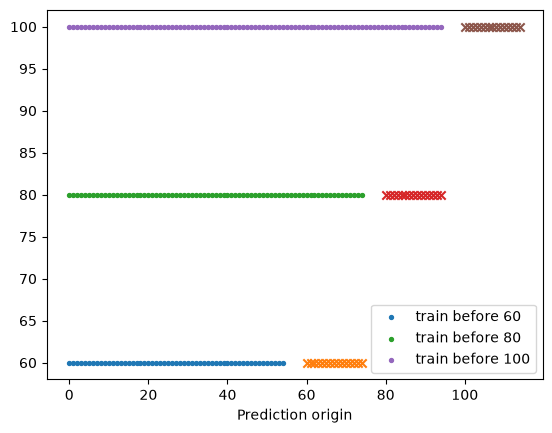

In [2]:
horizon=5;origins=np.arange(120);label_end=origins+horizon
for validation_start in [60,80,100]:
    train=origins[label_end<validation_start];valid=origins[(origins>=validation_start)&(origins<validation_start+15)]
    assert label_end[train].max()<valid.min()
    print("origin",validation_start,"last train origin",train[-1],"purged",validation_start-len(train))
    plt.scatter(train,np.full(len(train),validation_start),s=8,label=f"train before {validation_start}")
    plt.scatter(valid,np.full(len(valid),validation_start),marker="x")
plt.xlabel("Prediction origin");plt.legend();plt.show()

## Expected Observations

Purging depends on label availability, not a universal arbitrary gap. Overlapping validation labels still induce correlated errors and affect uncertainty estimates.

## Review Experiment

Before changing a parameter, write the direction you expect and why. Change only the parameter named in the guided experiment; rerun from a fresh kernel. Compare the observed result with your prediction. On a later review day, explain the code without reading the answers.

## English Check Questions

1. What quantity is this experiment estimating?
2. What information is available at prediction time?
3. Which observation would invalidate your conclusion?

## Reference Answers

1. A forecast made after close t may use returns through t. Its next-five-return label is only available after close t+5. At validation origin v, training examples must have label_end < v when the model is frozen before that origin.
2. Training inputs and their labels must be available before the relevant evaluation origin; preprocessing is fitted on training data only.
3. Purging depends on label availability, not a universal arbitrary gap. Overlapping validation labels still induce correlated errors and affect uncertainty estimates.

## Financial Connection

Transfer the timing, metric or deployment contract to the five-day volatility Workbench. A toy experiment verifies mechanics, not trading profitability.

## Sources

- https://scikit-learn.org/stable/common_pitfalls.html
- https://scikit-learn.org/stable/modules/cross_validation.html
- https://scikit-learn.org/stable/modules/model_evaluation.html

[Return to study page](../Study%20topics/time-series-splits-walk-forward-validation-temporal-leakage-forecast-horizons.html)
